
**Work Integrated Learning Programmes Division
Introduction to Data Science
S2-25_DSECLZG532
Assignment**


Group - 34
Names:
1. GAYATHRI SHARMA - 2025dc04062
2. SHIVNARAYAN V   - 2025dc04020
3. RISHABH KAUSHAL - 2025dc04016
4. KATHI DEEPTHI   - 2025dc04095

Dataset used : train.csv or (Mobile Price Prediction)

1. The required libraries are imported

In [1]:
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix,  roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, label_binarize
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC



2. The dataset is being read from csv file


In [2]:
df = pd.read_csv("train.csv", header = 'infer')
df.head()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,1,707,No,2.1,Yes,2,0,25,0.8,Med,...,495,574,3838,9,2,7,1,No,Yes,3
1,2,1218,No,1.8,Yes,1,1,14,0.5,Med,...,229,616,398,17,0,5,1,No,No,0
2,3,1986,No,0.5,No,7,0,51,0.4,Low,...,342,774,3165,5,0,13,1,No,No,3
3,4,1290,No,0.5,No,0,0,3,0.1,Med,...,600,1109,1214,9,8,15,0,Yes,Yes,1
4,5,1135,Yes,2.8,Yes,9,0,43,0.4,Med,...,690,1589,3204,18,13,6,1,No,No,3


In [3]:
len(df) # Total number of records / rows in dataset

2000

3. Data Preprocessing is done. Label encoding is done
It is used to convert to required labels ...categories to numericals

Then visualizing the correlation in betwwen each pair of features of the dataset.


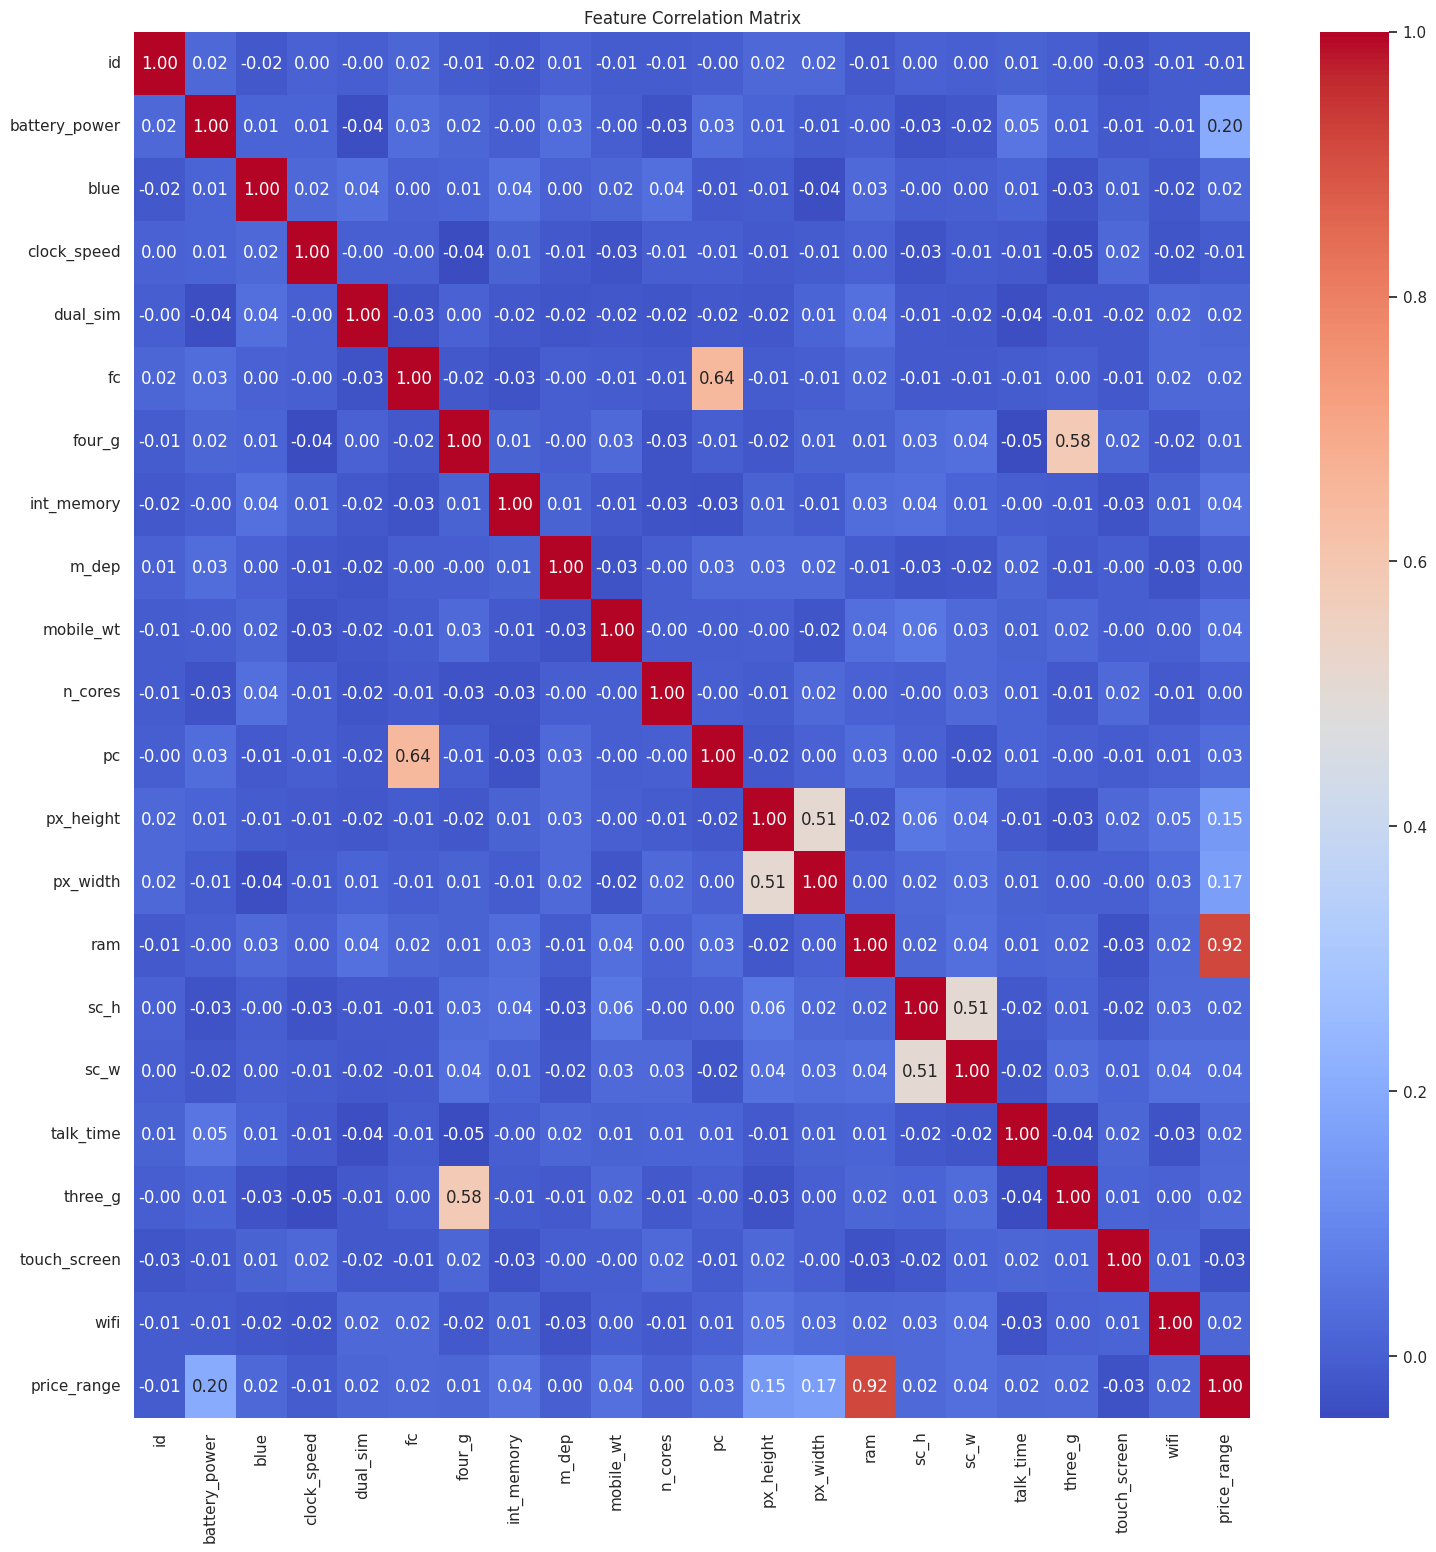

In [62]:
le = LabelEncoder() # Instantiation of LabelEncoder object

columns  = ['blue','dual_sim','mobile_wt','touch_screen','wifi']  # These are to be encoded
for i in columns:
  df[i] = le.fit_transform(df[i])



df.corr()  # Creating correlation matrix for each pair of the features of dataset

correlation_matrix = df.corr(method = 'pearson') # We are using Pearson correlation coeeficient

plt.figure(figsize=(18, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt="0.2f") # Visualizinf heatmap for correlation
plt.title('Feature Correlation Matrix')
plt.show()

In [5]:
# Displaying correlation of each features with output variable
target_correlation = df.corr()['price_range'].drop('price_range')
target_correlation


,price_range
id,-0.006469
battery_power,0.200723
blue,0.020573
clock_speed,-0.006606
dual_sim,0.017444
fc,0.021998
four_g,0.014772
int_memory,0.044435
m_dep,0.000853
mobile_wt,0.039323


In [6]:
df.columns # These are the feature names of dataset

Index(['id', 'battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc',
       'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [7]:
target_column = df.columns[-1]
target_column # This is the class to be predicted [0,1,2,3]

'price_range'

In [8]:
df[target_column]

,price_range
0,3
1,0
2,3
3,1
4,3
...,...
1995,3
1996,2
1997,2
1998,3


In [9]:
type(df) # Type of the dataset object

pandas.core.frame.DataFrame

4. Displaying datatypes of the features of dataset


In [10]:
j = 0
for i in df:
  j += 1
  print (type(i))
print(j)

<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
22


5. Displaying 1st 2 rows from the dataset

In [11]:
df[:2]

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,1,707,0,2.1,1,2,0,25,0.8,2,...,495,574,3838,9,2,7,1,0,1,3
1,2,1218,0,1.8,1,1,1,14,0.5,2,...,229,616,398,17,0,5,1,0,0,0


6. Checking if there're any null values

In [12]:
df.isna().sum()

,0
id,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0


7. Displaying the data in form of a Boxplot for visualization

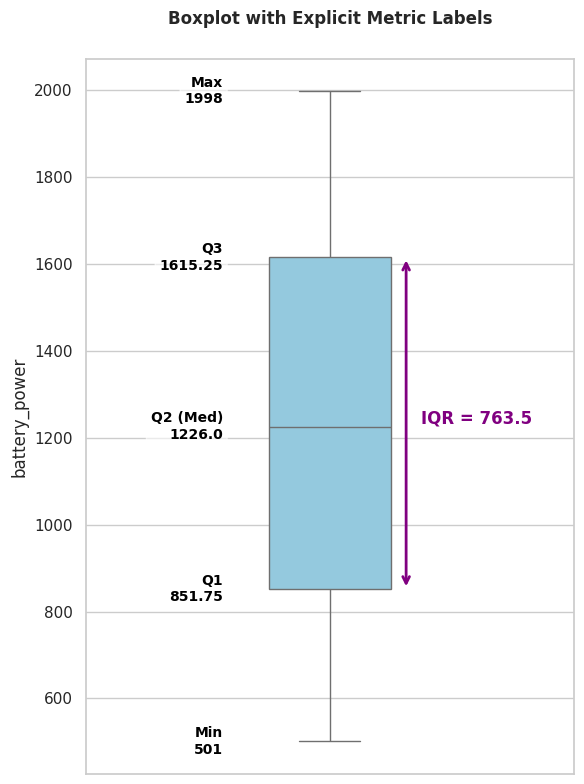

In [13]:
# Boxplot

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 8))


q1 = df["battery_power"].quantile(0.25) # Calculating quartile 1 value
q2 = df["battery_power"].quantile(0.50) # Calculating quartile 2 value / median
q3 = df["battery_power"].quantile(0.75) # Calculating quartile 3 value
iqr = q3 - q1  # Inter quartile range

lower_bound = q1 - 1.5 * iqr # minimum value
upper_bound = q3 + 1.5 * iqr # maximum value

whisker_min = df["battery_power"][df["battery_power"] >= lower_bound].min()
whisker_max = df["battery_power"][df["battery_power"] <= upper_bound].max()

ax = sns.boxplot(y=df["battery_power"], color="skyblue", width=0.4)

metrics = {
    "Min": whisker_min,
    "Q1": q1,
    "Q2 (Med)": q2,
    "Q3": q3,
    "Max": whisker_max,
}

for label, val in metrics.items():
    ax.text(
        y=val,
        x=-0.35,
        s=f"{label}\n{val}",
        ha="right",
        va="center",
        color="black",
        weight="bold",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.6, boxstyle="round,pad=0.3"),
    )

plt.annotate(
    "",
    xy=(0.25, q1),
    xytext=(0.25, q3),
    arrowprops=dict(arrowstyle="<->", color="purple", lw=2),
)
plt.text(0.3,(q1 + q3) / 2, f"IQR = {iqr}", ha="left", color="purple", weight="bold")

plt.title("Boxplot with Explicit Metric Labels", pad=25, weight="bold")
#plt.xlim(df["battery_power"].min() - 5, df["battery_power"].max() + 5)
plt.xlim(-0.8,0.8)
plt.tight_layout()
plt.show()

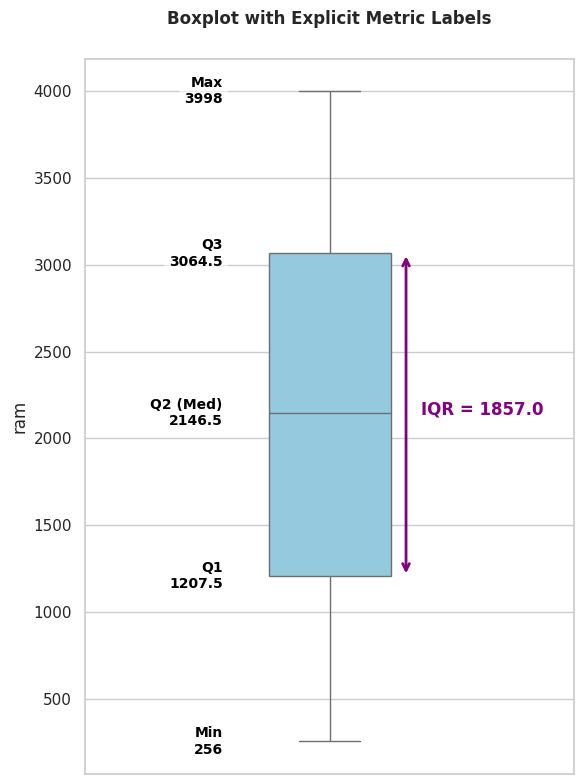

In [14]:
# Boxplot

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 8))


q1 = df["ram"].quantile(0.25)
q2 = df["ram"].quantile(0.50)
q3 = df["ram"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

whisker_min = df["ram"][df["ram"] >= lower_bound].min()
whisker_max = df["ram"][df["ram"] <= upper_bound].max()

ax = sns.boxplot(y=df["ram"], color="skyblue", width=0.4)

metrics = {
    "Min": whisker_min,
    "Q1": q1,
    "Q2 (Med)": q2,
    "Q3": q3,
    "Max": whisker_max,
}

for label, val in metrics.items():
    ax.text(
        y=val,
        x=-0.35,
        s=f"{label}\n{val}",
        ha="right",
        va="center",
        color="black",
        weight="bold",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.6, boxstyle="round,pad=0.3"),
    )

plt.annotate(
    "",
    xy=(0.25, q1),
    xytext=(0.25, q3),
    arrowprops=dict(arrowstyle="<->", color="purple", lw=2),
)
plt.text(0.3,(q1 + q3) / 2, f"IQR = {iqr}", ha="left", color="purple", weight="bold")

plt.title("Boxplot with Explicit Metric Labels", pad=25, weight="bold")
plt.xlim(-0.8,0.8)
plt.tight_layout()
plt.show()



8. Handling the null values based on datatype of the features. We use fill by mean, median for numerical columns and for boolean columns, we fill based on previous row's value

In [15]:
df['battery_power'] = df['battery_power'].fillna(df['battery_power'].mean())
df['battery_power']

df['clock_speed'] = df['clock_speed'].fillna(df['clock_speed'].mean())
df['clock_speed']

df['fc'] = df['fc'].fillna(df['fc'].mean())
df['fc']

df['int_memory'] = df['int_memory'].fillna(df['int_memory'].mean())
df['m_dep']= df['m_dep'].fillna(df['m_dep'].mean())
df['mobile_wt'] = df['mobile_wt'].fillna(df['mobile_wt'].mean())
df['n_cores'] = df['n_cores'].fillna(df['n_cores'].mode())
df['pc'] = df['pc'].fillna(df['pc'].median())
df['px_height'] = df['px_height'].fillna(df['px_height'].mean())
df['px_width'] = df['px_width'].fillna(df['px_width'].mean())
df['ram'] = df['ram'].fillna(df['ram'].mean())
df['sc_h'] = df['sc_h'].fillna(df['sc_h'].mean())
df['sc_w'] = df['sc_w'].fillna(df['sc_w'].mean())
df['talk_time'] = df['talk_time'].fillna(df['talk_time'].median())


In [16]:
import warnings

warnings.simplefilter('ignore', numpy.exceptions.RankWarning)
df['blue'] = df['blue'].fillna(method='ffill')
df['blue']

df['dual_sim'] = df['dual_sim'].fillna(method='ffill')
df['dual_sim']

df['four_g'] = df['four_g'].fillna(method = 'ffill')
df['four_g']
df['price_range']= df['price_range'].fillna(method = 'ffill')
df['three_g']= df['three_g'].fillna(method = 'ffill')
df['touch_screen']= df['touch_screen'].fillna(method = 'ffill')
df['wifi']= df['wifi'].fillna(method = 'ffill')

/tmp/ipykernel_592/2232901568.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['blue'] = df['blue'].fillna(method='ffill')
/tmp/ipykernel_592/2232901568.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['dual_sim'] = df['dual_sim'].fillna(method='ffill')
/tmp/ipykernel_592/2232901568.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['four_g'] = df['four_g'].fillna(method = 'ffill')
/tmp/ipykernel_592/2232901568.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['price_range']= df['price_range'].fillna(method = 'ffill')
/tmp/ipykernel_592/2232901568.py:13: FutureWarning: Series.fillna with 'method' is deprecated and

9. Inspection of class balance . Seeing how well the dataset is balanced with respect to the classes.

price_range
3.0    500
0.0    500
1.0    500
2.0    500
Name: count, dtype: int64
price_range
3.0    0.25
0.0    0.25
1.0    0.25
2.0    0.25
Name: proportion, dtype: float64


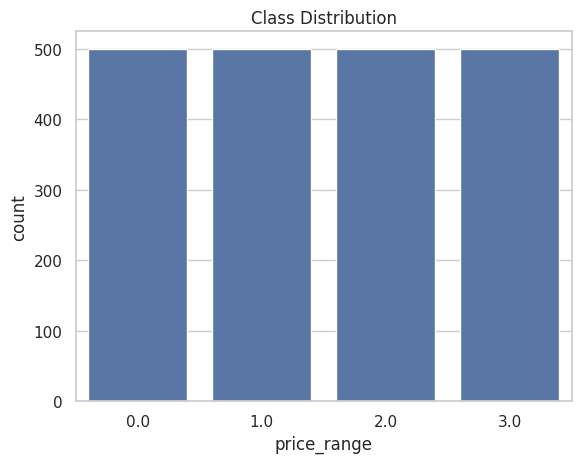

In [60]:
# Class Imbalance Ratio
print(df['price_range'].value_counts())
print(df['price_range'].value_counts(normalize=True))

sns.countplot(x='price_range', data=df)
plt.title('Class Distribution')
plt.show()


# The dataset is already perfectly balanaced, which means, each class has equal number of representatives from their sides.


In [18]:
# Basic Class Imbalance Handling ways

'''SMOTEENN: The pipeline begins by oversampling the minority class to artificially increase its size.Select a minority point: The algorithm picks a random sample P from the minority class.Find nearest neighbors: It locates the k-nearest neighbors of P that also belong to the minority class (typically k=5).Interpolate data: It randomly selects one neighbor Q and places a new synthetic data point Z along the line segment connecting P and Q.
Standard SMOTE often creates synthetic points that bleed into the majority class space, generating noise and blurring the class boundary. ENN functions as an undersampling mechanism to fix this:Evaluate neighbors: For every data point in the entire newly expanded dataset, ENN inspects its K-nearest neighbors (typically K=3) from both classes.Drop misclassifications: If a data point's class label does not match the majority class of its K-nearest neighbors, that point is flagged as an outlier or noise and deleted from the dataset

from imblearn.combine import SMOTEENN
X, y = sme.fit_resample(X_train, y_train)'''

"SMOTEENN: The pipeline begins by oversampling the minority class to artificially increase its size.Select a minority point: The algorithm picks a random sample P from the minority class.Find nearest neighbors: It locates the k-nearest neighbors of P that also belong to the minority class (typically k=5).Interpolate data: It randomly selects one neighbor Q and places a new synthetic data point Z along the line segment connecting P and Q.\nStandard SMOTE often creates synthetic points that bleed into the majority class space, generating noise and blurring the class boundary. ENN functions as an undersampling mechanism to fix this:Evaluate neighbors: For every data point in the entire newly expanded dataset, ENN inspects its K-nearest neighbors (typically K=3) from both classes.Drop misclassifications: If a data point's class label does not match the majority class of its K-nearest neighbors, that point is flagged as an outlier or noise and deleted from the dataset\n\nfrom imblearn.combi

10. Handling Outliers

In [19]:
# Outliers Handling

columns = ['battery_power','clock_speed','int_memory','mobile_wt','px_height','px_width','ram']

for i in columns:
  q1 = df[i].quantile(0.25)
  q3 = df[i].quantile(0.75)
  interQuantileRange = q3 - q1

  lowestElement = q1 - (1.5 * interQuantileRange)
  highestElement = q3 + (1.5 * interQuantileRange)

  df[i] = numpy.where(
    (df[i] < lowestElement) | (df[i] > highestElement),
    numpy.nan,
    df[i]
  )

#KNN Imputer predicts the missing values based on surrounding context
imputer = KNNImputer(n_neighbors=3)
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

11. Performing further data preprocessing like minmax scling which makes sure that data is restricted to max and min value of that feautre..then, we apply standard scaler that ensures thaat data will have near 0 mean and 1 as variance(standard deviation).

Minmax -> Best for data with fixed physical limits.
Standard Scaler -> continuous data ( preserves the variance patterns )

In [20]:
# MINMAX AND STD SCALER'S

minmax_scaled = ['clock_speed', 'n_cores', 'talk_time', 'm_dep', 'sc_h', 'sc_w']
standard_scaled = ['ram', 'battery_power', 'px_height', 'px_width', 'mobile_wt', 'pc', 'fc']

minmaxscaler = MinMaxScaler()
standardscaler = StandardScaler()

dataset_scaled = df.copy()
for col in minmax_scaled:
    dataset_scaled[[col]] = minmaxscaler.fit_transform(dataset_scaled[[col]])

for col in standard_scaled:
    dataset_scaled[[col]] = standardscaler.fit_transform(dataset_scaled[[col]])

In [21]:
# VERIFICATION

dataset_scaled['ram'].std()

1.0002500937890806

In [22]:
dataset_scaled

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,1.0,-1.209899,0.0,0.64,1.0,-0.532099,0.0,25.0,0.777778,1.048863,...,-0.337927,-1.567991,1.580312,0.285714,0.111111,0.277778,1.0,0.0,1.0,3.0
1,2.0,-0.046706,0.0,0.52,1.0,-0.762495,1.0,14.0,0.444444,1.048863,...,-0.939500,-1.470790,-1.591771,0.857143,0.000000,0.166667,1.0,0.0,0.0,0.0
2,3.0,1.701496,0.0,0.00,0.0,0.619880,0.0,51.0,0.333333,-0.207260,...,-0.683945,-1.105126,0.959728,0.000000,0.000000,0.611111,1.0,0.0,0.0,3.0
3,4.0,0.117188,0.0,0.00,0.0,-0.992890,0.0,3.0,0.000000,1.048863,...,-0.100464,-0.329827,-0.839323,0.285714,0.444444,0.722222,0.0,1.0,1.0,1.0
4,5.0,-0.235640,1.0,0.92,1.0,1.080671,0.0,43.0,0.333333,1.048863,...,0.103076,0.781049,0.995690,0.928571,0.722222,0.222222,1.0,0.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996.0,1.694667,1.0,0.28,1.0,0.389484,1.0,27.0,0.555556,1.048863,...,-0.620621,-0.126167,1.634717,0.500000,0.555556,0.444444,1.0,1.0,1.0,3.0
1996,1997.0,-0.454165,1.0,0.88,0.0,1.541463,0.0,56.0,0.222222,1.048863,...,-0.333404,-1.466161,0.904401,0.642857,0.444444,0.166667,0.0,1.0,1.0,2.0
1997,1998.0,0.551962,1.0,0.08,1.0,-0.071307,1.0,37.0,0.555556,-0.207260,...,-1.195056,0.651447,0.756862,0.357143,0.277778,0.777778,1.0,1.0,1.0,2.0
1998,1999.0,1.332735,1.0,0.56,1.0,1.080671,1.0,2.0,0.666667,-0.207260,...,-1.344318,-0.339085,1.690967,0.500000,0.111111,0.944444,1.0,1.0,0.0,3.0


In [23]:
dataset_scaled['price_range'].unique()

array([3., 0., 1., 2.])

12. Splitting dataset to train and test sets

In [24]:
# TRAIN TEST SETS SPLIT

X = dataset_scaled.drop(['id','price_range'], axis=1)
y = dataset_scaled['price_range']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1500, 20) (500, 20) (1500,) (500,)


13. Visualizing the relation between features

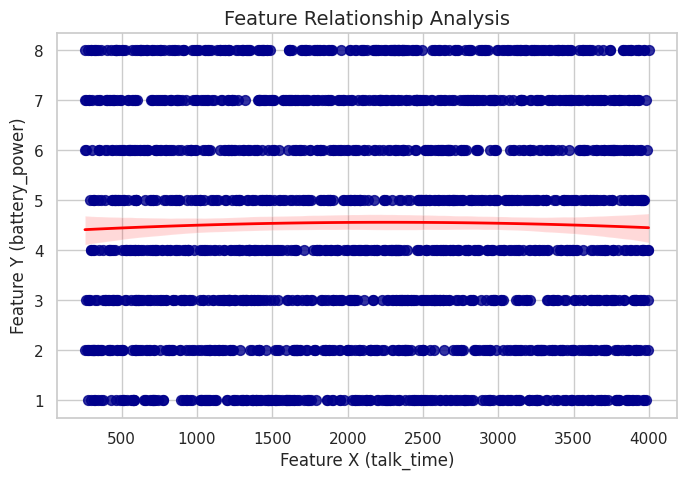

In [25]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="ram",
    y="n_cores",
    order=2,
    scatter_kws={"s": 50, "color": "darkblue"},
    line_kws={"color": "red", "lw": 2},
)

plt.title("Feature Relationship Analysis", fontsize=14)
plt.xlabel("Feature X (talk_time)", fontsize=12)
plt.ylabel("Feature Y (battery_power)", fontsize=12)

plt.show()

In [91]:
g = sns.PairGrid(df, height=2.5)
import warnings

warnings.simplefilter('ignore', numpy.exceptions.RankWarning)

# 4. Map the plots: Distributions on diagonal, Curve-fitted Regplots on off-diagonal
g.map_diag(sns.histplot, kde=True, color="darkblue")
g.map_offdiag(
    sns.regplot,
    order=2,
    scatter_kws={"s": 10, "alpha": 0.5, "color": "darkblue"},
    line_kws={"color": "red", "lw": 1.5},
)
plt.close(g.fig)
#plt.show()

In [59]:
# MODELS

# Feature Selection

# Pearson + Random Forest

feat_corr = df.drop(['id','price_range'], axis=1).corr(method = "spearman").abs()
threshold_value_corr = 0.35

upper_tri = feat_corr.where(numpy.triu(numpy.ones(feat_corr.shape), k=1).astype(bool))

to_retain = [column for column in upper_tri.columns if any(upper_tri[column] >= threshold_value_corr)]
print(to_retain)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

accuracy_before = rf.score(X_test, y_test)
accuracy_before

['pc', 'px_width', 'sc_w', 'three_g']


0.89

In [28]:
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

          Feature  Importance
13            ram    0.479452
0   battery_power    0.076610
12       px_width    0.057920
11      px_height    0.056401
6      int_memory    0.039692
16      talk_time    0.032435
2     clock_speed    0.031997
14           sc_h    0.030490
15           sc_w    0.030108
10             pc    0.029079
7           m_dep    0.027256
4              fc    0.027008
9         n_cores    0.025742
8       mobile_wt    0.012708
18   touch_screen    0.007741
3        dual_sim    0.007666
19           wifi    0.007350
1            blue    0.006973
5          four_g    0.006801
17        three_g    0.006570


          Feature  Selected  Rank
0   battery_power      True     1
13            ram      True     1
11      px_height      True     1
14           sc_h      True     1
12       px_width      True     1
9         n_cores      True     1
15           sc_w     False     2
19           wifi     False     3
7           m_dep     False     4
17        three_g     False     5
16      talk_time     False     6
18   touch_screen     False     7
5          four_g     False     8
8       mobile_wt     False     9
3        dual_sim     False    10
2     clock_speed     False    11
1            blue     False    12
4              fc     False    13
10             pc     False    14
6      int_memory     False    15
[ True False False False False False False False False  True False  True
  True  True  True False False False False False]
Accuracy Score: 0.954

Confusion Matrix:
 [[124   4   0   0]
 [  4 119   1   0]
 [  0   6 127   4]
 [  0   0   4 107]]

Classification Report:
               preci

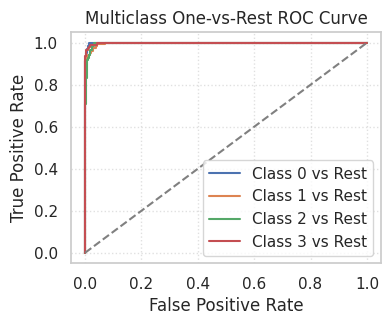

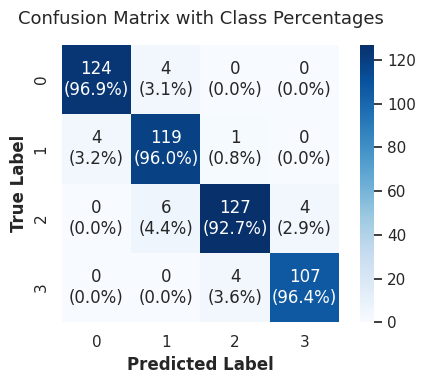

In [68]:
# Feature selection and model fitting

# 1. Logistic regresison
log_reg = LogisticRegression(max_iter=1000, random_state=42)

rfe = RFE(estimator=log_reg, n_features_to_select=6)
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)

feature_ranking = pd.DataFrame(
    {"Feature": df.columns.drop(['price_range','id']), "Selected": rfe.support_, "Rank": rfe.ranking_})

print(feature_ranking.sort_values(by="Rank"))

print(rfe.support_)
X_train_final = X_train.loc[:, rfe.support_]
X_test_final = X_test.loc[:, rfe.support_]
final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_train_final, y_train)

y_pred_final = final_model.predict(X_test_final)
y_probs_final = final_model.predict_proba(X_test_final)


print("Accuracy Score:", accuracy_score(y_test, y_pred_final))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))


# AUC Curve
macro_auc = roc_auc_score(y_test, y_probs_final, multi_class="ovr")
classes = [0,1,2,3]
y_test_binarized = label_binarize(y_test, classes=classes)

plt.figure(figsize=(4, 3))
for i in range(4):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_probs_final[:, i])
    plt.plot(fpr, tpr, label=f"Class {classes[i]} vs Rest")

plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass One-vs-Rest ROC Curve")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_final)
cm_percentages = cm.astype("float") / cm.sum(axis=1)[:, numpy.newaxis]

labels = [
    f"{count}\n({pct:.1%})"
    for count, pct in zip(cm.flatten(), cm_percentages.flatten())
]
labels = numpy.asarray(labels).reshape(4, 4)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    square=True,
)
plt.xlabel("Predicted Label", fontweight="bold")
plt.ylabel("True Label", fontweight="bold")
plt.title("Confusion Matrix with Class Percentages", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

In [30]:
# 2. Random Forest

# Train the Random Forest model with selected features
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selected.fit(X_train_final, y_train)

# Evaluate the model
accuracy_after = rf_selected.score(X_test_final, y_test)
print(f'Accuracy after feature selection: {accuracy_after:.2f}')

Accuracy after feature selection: 0.91


In [31]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import DecisionBoundaryDisplay

# GRID SEARCH
param_grid = [
    {
        'kernel': ['rbf'],
        'C': [0.1, 100 ],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10, 100],
        'degree': [2, 3, 4],
        'gamma': ['scale', 'auto']
    }
]

grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_final, y_train)

svm_model = grid_search.best_estimator_
print(f"Best Parameters Found: {grid_search.best_params_}")


y_pred_svm = svm_model.predict(X_test_final)
y_probs_svm = svm_model.predict_proba(X_test_final)

svm_acc = accuracy_score(y_test, y_pred_svm)
print(f"=== Optimized SVM ({grid_search.best_params_['kernel'].upper()} Kernel) Accuracy: {svm_acc:.2f} ===")



Best Parameters Found: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
=== Optimized SVM (RBF Kernel) Accuracy: 0.96 ===


=== SVM Linear Kernel Accuracy: 0.96 ===


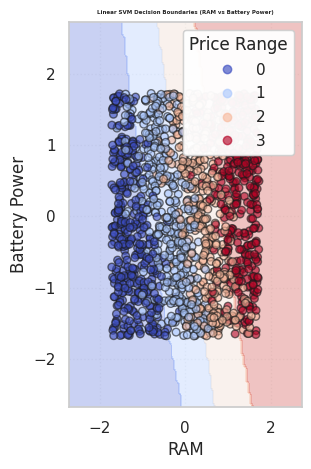

In [58]:
# 3. SVM

svm_model = SVC(kernel="rbf", C=100, probability=True, random_state=42, gamma = 0.01)

svm_model.fit(X_train_final, y_train)

y_pred_svm = svm_model.predict(X_test_final)
y_probs_svm = svm_model.predict_proba(X_test_final)

svm_acc = accuracy_score(y_test, y_pred_svm)
print(f"=== SVM Linear Kernel Accuracy: {svm_acc:.2f} ===")


from sklearn.inspection import DecisionBoundaryDisplay

X_2d = X_train_final[['ram', 'battery_power']]

svm_2d = SVC(kernel="rbf", C=100, random_state=42, gamma = 0.01)
svm_2d.fit(X_2d, y_train)

fig, ax = plt.subplots(figsize=(3, 5))

DecisionBoundaryDisplay.from_estimator(
    svm_2d,
    X_2d,
    response_method="predict",
    cmap="coolwarm",
    alpha=0.3,
    ax=ax,
    xlabel="RAM",
    ylabel="Battery Power"
)

scatter = ax.scatter(
    X_2d['ram'],
    X_2d['battery_power'],
    c=y_train,
    cmap="coolwarm",
    edgecolors="k",
    alpha=0.6,
    s=30
)

legend = ax.legend(*scatter.legend_elements(), title="Price Range", loc="upper right")
ax.add_artist(legend)
plt.title("Linear SVM Decision Boundaries (RAM vs Battery Power)", fontsize=4, fontweight='bold')
plt.grid(True, linestyle=":", alpha=0.2)
plt.show()


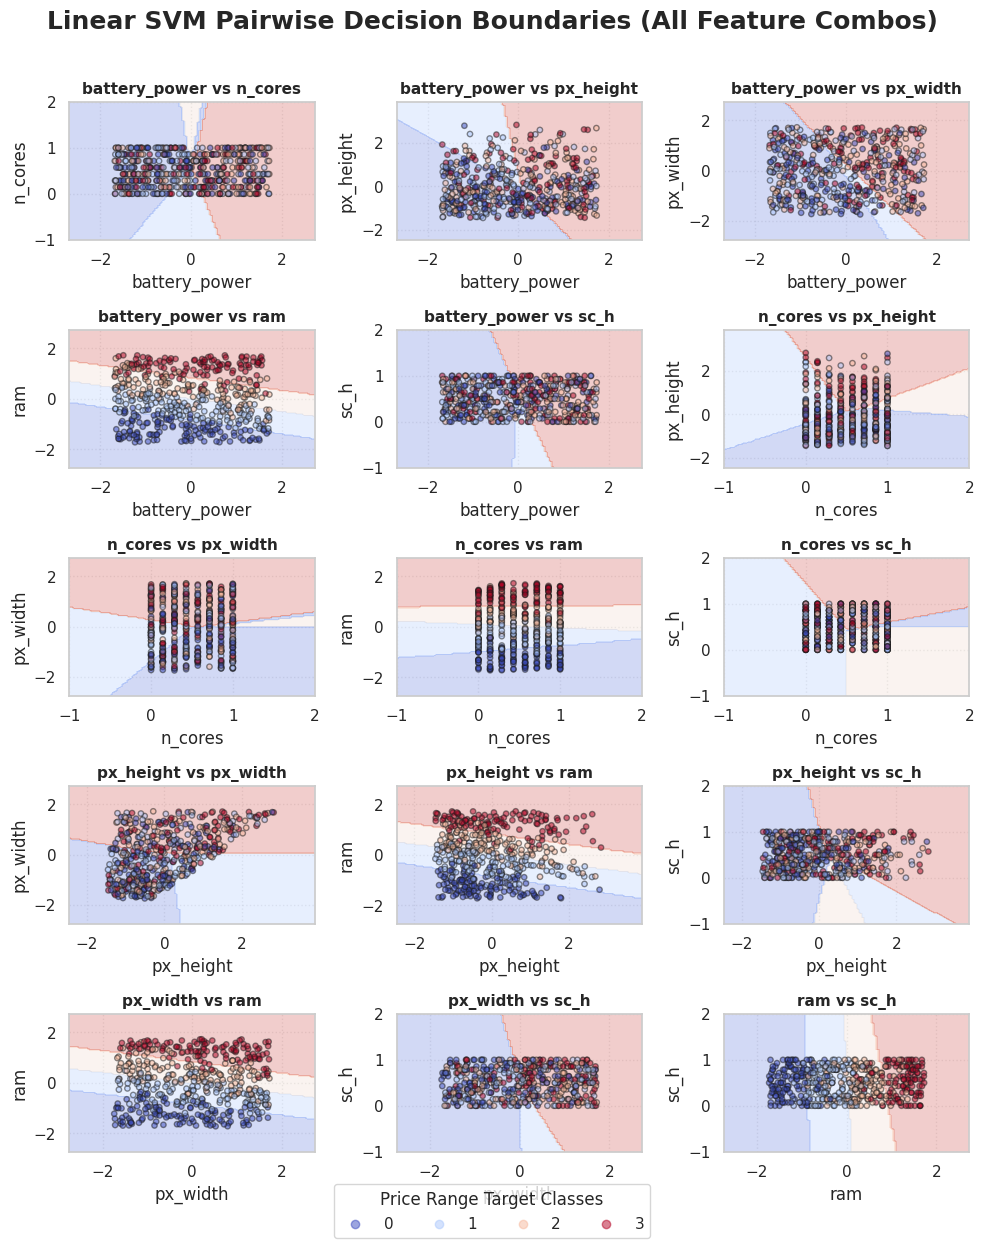

In [69]:
import itertools

feature_names = X_train_final.columns.tolist()

feature_pairs = list(itertools.combinations(feature_names, 2))

fig, axes = plt.subplots(5, 3, figsize=(10, 12))
axes = axes.flatten()
fig.suptitle(
    "Linear SVM Pairwise Decision Boundaries (All Feature Combos)",
    fontsize=18,
    fontweight="bold",
    y=1.01,
)

for idx, (feat_x, feat_y) in enumerate(feature_pairs):
    ax = axes[idx]

    X_train_2d = X_train_final[[feat_x, feat_y]]
    X_test_2d = X_test_final[[feat_x, feat_y]]

    svm_2d = SVC(kernel="linear", C=10.0, random_state=42)
    svm_2d.fit(X_train_2d, y_train)

    DecisionBoundaryDisplay.from_estimator(
        svm_2d,
        X_train_2d,
        response_method="predict",
        cmap="coolwarm",
        alpha=0.25,
        ax=ax,
        xlabel=feat_x,
        ylabel=feat_y,
    )

    scatter = ax.scatter(
        X_test_2d[feat_x],
        X_test_2d[feat_y],
        c=y_test,
        cmap="coolwarm",
        edgecolors="k",
        alpha=0.5,
        s=15,
    )

    ax.set_title(f"{feat_x} vs {feat_y}", fontsize=11, fontweight="bold")
    ax.grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()

handles, labels = scatter.legend_elements()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    title="Price Range Target Classes",
    bbox_to_anchor=(0.5, -0.02),
    fontsize=11,
    title_fontsize=12,
)

plt.show()


### Random Forest Model Evaluation

Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.95      0.95       128
         1.0       0.86      0.92      0.89       124
         2.0       0.90      0.84      0.87       137
         3.0       0.92      0.92      0.92       111

    accuracy                           0.91       500
   macro avg       0.91      0.91      0.91       500
weighted avg       0.91      0.91      0.91       500



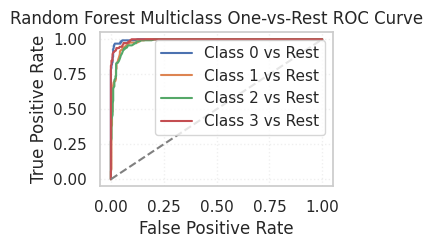

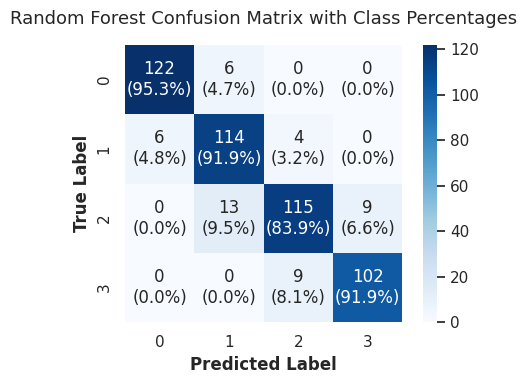

In [75]:
# Get predictions and probabilities for Random Forest
y_pred_rf = rf_selected.predict(X_test_final)
y_probs_rf = rf_selected.predict_proba(X_test_final)

# Classification Report
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# AUC Curve
plt.figure(figsize=(3, 2))
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_probs_rf[:, i])
    plt.plot(fpr, tpr, label=f"Class {classes[i]} vs Rest")

plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest Multiclass One-vs-Rest ROC Curve")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.3)
plt.show()

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_percentages_rf = cm_rf.astype("float") / cm_rf.sum(axis=1)[:, numpy.newaxis]

labels_rf = [
    f"{count}\n({pct:.1%})"
    for count, pct in zip(cm_rf.flatten(), cm_percentages_rf.flatten())
]
labels_rf = numpy.asarray(labels_rf).reshape(len(classes), len(classes))

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf,
    annot=labels_rf,
    fmt="",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    square=True,
)
plt.xlabel("Predicted Label", fontweight="bold")
plt.ylabel("True Label", fontweight="bold")
plt.title("Random Forest Confusion Matrix with Class Percentages", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

### SVM Model Evaluation

SVM Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       128
         1.0       0.94      0.98      0.96       124
         2.0       0.96      0.94      0.95       137
         3.0       0.97      0.96      0.97       111

    accuracy                           0.96       500
   macro avg       0.96      0.96      0.96       500
weighted avg       0.96      0.96      0.96       500



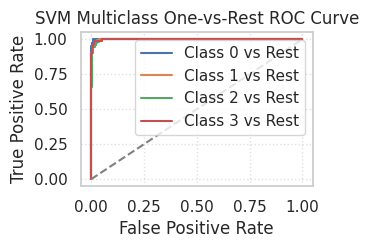

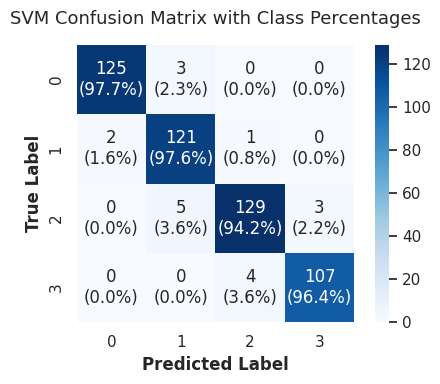

In [76]:
# Classification Report
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

# AUC Curve (y_probs_svm is already available from previous cell)
plt.figure(figsize=(3, 2))
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_probs_svm[:, i])
    plt.plot(fpr, tpr, label=f"Class {classes[i]} vs Rest")

plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM Multiclass One-vs-Rest ROC Curve")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_percentages_svm = cm_svm.astype("float") / cm_svm.sum(axis=1)[:, numpy.newaxis]

labels_svm = [
    f"{count}\n({pct:.1%})"
    for count, pct in zip(cm_svm.flatten(), cm_percentages_svm.flatten())
]
labels_svm = numpy.asarray(labels_svm).reshape(len(classes), len(classes))

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_svm,
    annot=labels_svm,
    fmt="",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    square=True,
)
plt.xlabel("Predicted Label", fontweight="bold")
plt.ylabel("True Label", fontweight="bold")
plt.title("SVM Confusion Matrix with Class Percentages", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

In [37]:
# 4. Neural Network

import torch
import torch.nn as nn
import torch.optim as optim


X_train_t = torch.tensor(X_train_final.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)
X_test_t = torch.tensor(X_test_final.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)


class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()

        self.network = nn.Sequential(
            # Layer 1: Input to Hidden
            nn.Linear(6, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            # Layer 2: Hidden to Hidden
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.05),

            # Layer 3: Output Class Logits
            nn.Linear(32, 4)
        )

    def forward(self, x):

        return self.network(x)

model = SimpleNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

epochs = 70

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    loss.backward()
    optimizer.step()

    scheduler.step(loss.item())

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{epochs} | Training Loss: {loss.item():.4f}")

model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t)
    _, test_preds = torch.max(test_outputs, dim=1)

test_accuracy = accuracy_score(y_test_t.numpy(), test_preds.numpy())
print(f"\n Final Test Accuracy: {test_accuracy * 100:.2f}%")
nerual_network_model = model


Epoch 01/70 | Training Loss: 1.3361
Epoch 10/70 | Training Loss: 0.5181
Epoch 20/70 | Training Loss: 0.2417
Epoch 30/70 | Training Loss: 0.1519
Epoch 40/70 | Training Loss: 0.1140
Epoch 50/70 | Training Loss: 0.0955
Epoch 60/70 | Training Loss: 0.0840
Epoch 70/70 | Training Loss: 0.0696

 Final Test Accuracy: 95.40%


In [38]:
from sklearn.metrics import classification_report, confusion_matrix

print("Test Performance Details:")
print(classification_report(y_test_t.numpy(), test_preds.numpy(),
                            target_names=["0","1","2","3"]))

print(" Confusion Matrix:")
print(confusion_matrix(y_test_t.numpy(), test_preds.numpy()))


Test Performance Details:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       128
           1       0.94      0.96      0.95       124
           2       0.95      0.91      0.93       137
           3       0.95      0.95      0.95       111

    accuracy                           0.95       500
   macro avg       0.95      0.95      0.95       500
weighted avg       0.95      0.95      0.95       500

 Confusion Matrix:
[[128   0   0   0]
 [  4 119   1   0]
 [  0   7 125   5]
 [  0   0   6 105]]


Text(2, 1, 'blue=1')

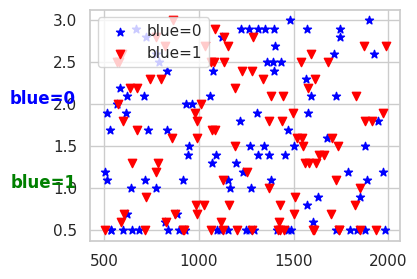

In [83]:
# Scatter plot
plt.figure(figsize=(4, 3))
df1=df[df['blue']==0][:100]
df2=df[df['blue']==1][:100]

plt.scatter(df1['battery_power'],df1['clock_speed'],color='blue', marker= '*', label='blue=0')
plt.scatter(df2['battery_power'],df2['clock_speed'],color= 'red', marker='v', label='blue=1')
plt.legend()

plt.text(1, 2, "blue=0", horizontalalignment='left', size='medium', color='blue', weight='semibold')
plt.text(2, 1, "blue=1", horizontalalignment='left', size='medium', color='green', weight='semibold')


Text(2.2, 1, 'touch_screen=1')

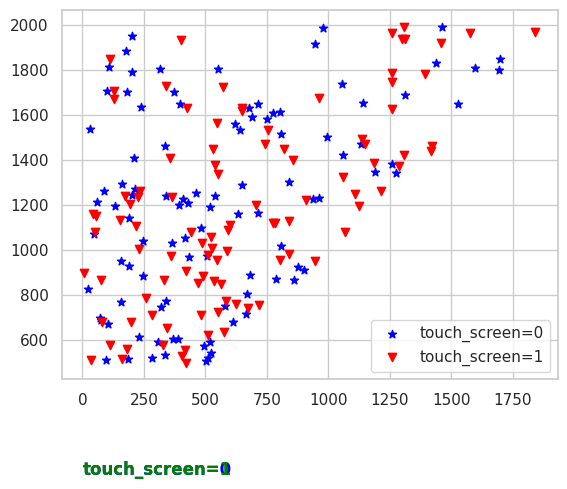

In [87]:
# Scatter plot 2
df1=df[df['touch_screen']==0][:100]
df2=df[df['touch_screen']==1][:100]

plt.scatter(df1['px_height'],df1['px_width'],color='blue', marker= '*', label='touch_screen=0')
plt.scatter(df2['px_height'],df2['px_width'],color= 'red', marker='v', label='touch_screen=1')
plt.legend()

plt.text(2.5+0.2, 2, "touch_screen=0", horizontalalignment='left', size='medium', color='blue', weight='semibold')
plt.text(2+0.2, 1, "touch_screen=1", horizontalalignment='left', size='medium', color='green', weight='semibold')


/tmp/ipykernel_592/3250570.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = i, data = df, palette="coolwarm_r")
/tmp/ipykernel_592/3250570.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = i, data = df, palette="coolwarm_r")
/tmp/ipykernel_592/3250570.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = i, data = df, palette="coolwarm_r")


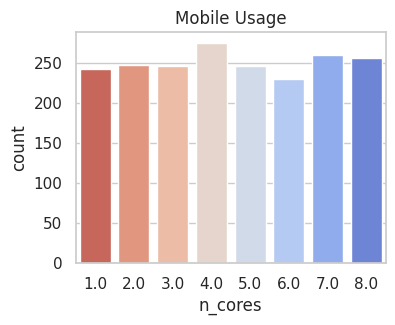

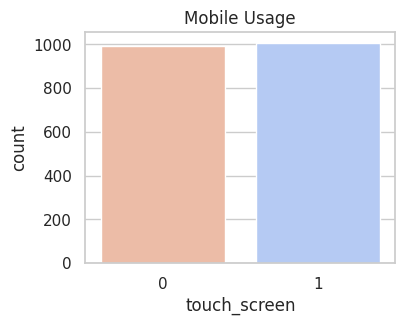

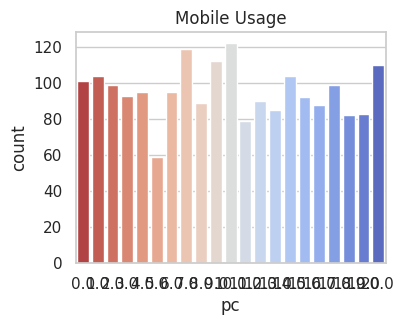

In [89]:
# CountPlots
columns_countplot = ['n_cores','touch_screen','pc']
for i in columns_countplot:
  plt.figure(figsize=(4,3))
  ax = sns.countplot(x = i, data = df, palette="coolwarm_r")
  plt.title('Mobile Usage', fontsize=12)

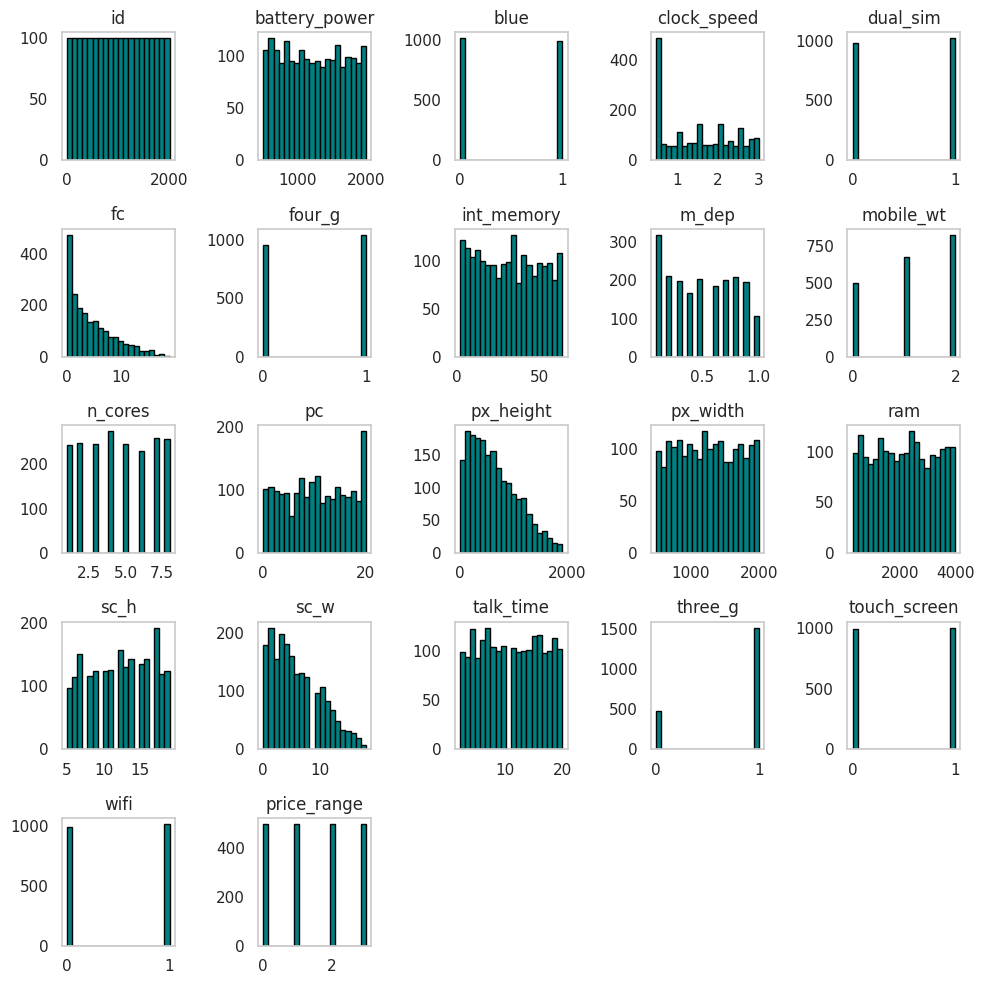

In [90]:
df.hist(bins=20, figsize=(10, 10), grid=False, edgecolor='black', color='teal')
plt.tight_layout()
plt.show()

## Resources

### 1. Load and Preprocess Test Data
Now, let's load the `test.csv` dataset and apply the same preprocessing steps that were applied to the `train.csv` data. This includes label encoding, outlier handling, and scaling.

In [43]:
df_test = pd.read_csv("test.csv", header = 'infer')
df_test.head()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,Unnamed: 21,Unnamed: 22
0,1,1500,Yes,1.8,Yes,14,0,5,0.1,High,...,1200,2056,10,7,2,0,Yes,No,NaN,NaN
1,2,841,Yes,0.5,Yes,4,1,61,0.8,High,...,857,3895,6,0,7,1,No,No,NaN,NaN
2,3,1807,Yes,2.8,No,1,0,27,0.9,High,...,1366,2396,17,10,10,0,Yes,Yes,NaN,
3,4,1546,No,0.5,Yes,18,1,25,0.5,Low,...,1752,3893,10,0,7,1,Yes,No,NaN,NaN
4,5,1434,No,1.4,No,11,1,49,0.5,Low,...,810,1773,15,8,7,1,No,Yes,NaN,NaN


In [44]:
le = LabelEncoder() # Instantiation of LabelEncoder object

columns  = ['blue','dual_sim','mobile_wt','touch_screen','wifi']  # These are to be encoded
for i in columns:
  df_test[i] = le.fit_transform(df_test[i])

df_test.head()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,Unnamed: 21,Unnamed: 22
0,1,1500,1,1.8,1,14,0,5,0.1,0,...,1200,2056,10,7,2,0,1,0,NaN,NaN
1,2,841,1,0.5,1,4,1,61,0.8,0,...,857,3895,6,0,7,1,0,0,NaN,NaN
2,3,1807,1,2.8,0,1,0,27,0.9,0,...,1366,2396,17,10,10,0,1,1,NaN,
3,4,1546,0,0.5,1,18,1,25,0.5,1,...,1752,3893,10,0,7,1,1,0,NaN,NaN
4,5,1434,0,1.4,0,11,1,49,0.5,1,...,810,1773,15,8,7,1,0,1,NaN,NaN


In [45]:
# Outliers Handling - applying the same logic as for training data

# Drop unnamed columns that might have appeared due to data loading issues in test.csv
unnamed_cols = [col for col in df_test.columns if 'Unnamed:' in col]
if unnamed_cols:
    df_test = df_test.drop(columns=unnamed_cols)

columns = ['battery_power','clock_speed','int_memory','mobile_wt','px_height','px_width','ram']

for i in columns:
  q1 = df_test[i].quantile(0.25)
  q3 = df_test[i].quantile(0.75)
  interQuantileRange = q3 - q1

  lowestElement = q1 - (1.5 * interQuantileRange)
  highestElement = q3 + (1.5 * interQuantileRange)

  df_test[i] = numpy.where(
    (df_test[i] < lowestElement) | (df_test[i] > highestElement),
    numpy.nan,
    df_test[i]
  )

#KNN Imputer predicts the missing values based on surrounding context
imputer = KNNImputer(n_neighbors=3)
df_test = pd.DataFrame(imputer.fit_transform(df_test), columns=df_test.columns)
df_test.head()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1.0,1500.0,1.0,1.8,1.0,14.0,0.0,5.0,0.1,0.0,...,16.0,1600.0,1200.0,2056.0,10.0,7.0,2.0,0.0,1.0,0.0
1,2.0,841.0,1.0,0.5,1.0,4.0,1.0,61.0,0.8,0.0,...,12.0,746.0,857.0,3895.0,6.0,0.0,7.0,1.0,0.0,0.0
2,3.0,1807.0,1.0,2.8,0.0,1.0,0.0,27.0,0.9,0.0,...,4.0,1270.0,1366.0,2396.0,17.0,10.0,10.0,0.0,1.0,1.0
3,4.0,1546.0,0.0,0.5,1.0,18.0,1.0,25.0,0.5,1.0,...,20.0,295.0,1752.0,3893.0,10.0,0.0,7.0,1.0,1.0,0.0
4,5.0,1434.0,0.0,1.4,0.0,11.0,1.0,49.0,0.5,1.0,...,18.0,749.0,810.0,1773.0,15.0,8.0,7.0,1.0,0.0,1.0


In [46]:
minmax_scaled = ['clock_speed', 'n_cores', 'talk_time', 'm_dep', 'sc_h', 'sc_w']
standard_scaled = ['ram', 'battery_power', 'px_height', 'px_width', 'mobile_wt', 'pc', 'fc']

minmaxscaler = MinMaxScaler()
standardscaler = StandardScaler()

dataset_test_scaled = df_test.copy()
for col in minmax_scaled:
    dataset_test_scaled[[col]] = minmaxscaler.fit_transform(dataset_test_scaled[[col]])

for col in standard_scaled:
    dataset_test_scaled[[col]] = standardscaler.fit_transform(dataset_test_scaled[[col]])
dataset_test_scaled.head()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1.0,0.580737,1.0,0.52,1.0,2.108676,0.0,5.0,0.000000,-1.438941,...,0.976026,2.265122,-0.090033,-0.075068,0.357143,0.388889,0.000000,0.0,1.0,0.0
1,2.0,-0.943787,1.0,0.00,1.0,-0.132927,1.0,61.0,0.777778,-1.438941,...,0.319433,0.278654,-0.870609,1.617168,0.071429,0.000000,0.277778,1.0,0.0,0.0
2,3.0,1.290948,1.0,0.92,0.0,-0.805408,0.0,27.0,0.888889,-1.438941,...,-0.993754,1.497517,0.287739,0.237798,0.857143,0.555556,0.444444,0.0,1.0,1.0
3,4.0,0.687153,0.0,0.00,1.0,3.005317,1.0,25.0,0.444444,-0.184415,...,1.632619,-0.770406,1.166171,1.615328,0.357143,0.000000,0.277778,1.0,1.0,0.0
4,5.0,0.428054,0.0,0.36,0.0,1.436195,1.0,49.0,0.444444,-0.184415,...,1.304323,0.285632,-0.977568,-0.335482,0.714286,0.444444,0.277778,1.0,0.0,1.0


### 2. Make Predictions on Test Data
Now that the test data has been preprocessed, we can use one of the trained models to make predictions. We'll use the Logistic Regression model (`final_model`) that was trained earlier.

In [47]:
# Prepare test data for prediction (drop 'id' column and select features based on RFE)
X_test_submission = dataset_test_scaled.drop(['id'], axis=1)

X_test_final_submission = X_test_submission.loc[:, rfe.support_]

# Make predictions using the trained Logistic Regression model
predictions = final_model.predict(X_test_final_submission)

# Display the first few predictions
print("First 10 predictions on the test set:")
print(predictions[:10])

# Optionally, add predictions back to the test dataframe
df_test['predicted_price_range'] = predictions
print("\nTest DataFrame with predictions:")
display(df_test.head())

First 10 predictions on the test set:
[2. 3. 3. 3. 1. 3. 3. 1. 3. 0.]

Test DataFrame with predictions:


,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,predicted_price_range
0,1.0,1500.0,1.0,1.8,1.0,14.0,0.0,5.0,0.1,0.0,...,1600.0,1200.0,2056.0,10.0,7.0,2.0,0.0,1.0,0.0,2.0
1,2.0,841.0,1.0,0.5,1.0,4.0,1.0,61.0,0.8,0.0,...,746.0,857.0,3895.0,6.0,0.0,7.0,1.0,0.0,0.0,3.0
2,3.0,1807.0,1.0,2.8,0.0,1.0,0.0,27.0,0.9,0.0,...,1270.0,1366.0,2396.0,17.0,10.0,10.0,0.0,1.0,1.0,3.0
3,4.0,1546.0,0.0,0.5,1.0,18.0,1.0,25.0,0.5,1.0,...,295.0,1752.0,3893.0,10.0,0.0,7.0,1.0,1.0,0.0,3.0
4,5.0,1434.0,0.0,1.4,0.0,11.0,1.0,49.0,0.5,1.0,...,749.0,810.0,1773.0,15.0,8.0,7.0,1.0,0.0,1.0,1.0


### Making Predictions with Random Forest Model

In [48]:
# Make predictions using the trained Random Forest model
predictions_rf = rf_selected.predict(X_test_final_submission)

# Optionally, add predictions back to the test dataframe (if not already done)
df_test['predicted_price_range_rf'] = predictions_rf

# Display the first few predictions
print("First 10 predictions on the test set using Random Forest:")
print(predictions_rf[:10])
print("\nTest DataFrame with Random Forest predictions:")
display(df_test.head())

First 10 predictions on the test set using Random Forest:
[2. 3. 2. 3. 1. 3. 3. 1. 3. 0.]

Test DataFrame with Random Forest predictions:


,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,predicted_price_range,predicted_price_range_rf
0,1.0,1500.0,1.0,1.8,1.0,14.0,0.0,5.0,0.1,0.0,...,1200.0,2056.0,10.0,7.0,2.0,0.0,1.0,0.0,2.0,2.0
1,2.0,841.0,1.0,0.5,1.0,4.0,1.0,61.0,0.8,0.0,...,857.0,3895.0,6.0,0.0,7.0,1.0,0.0,0.0,3.0,3.0
2,3.0,1807.0,1.0,2.8,0.0,1.0,0.0,27.0,0.9,0.0,...,1366.0,2396.0,17.0,10.0,10.0,0.0,1.0,1.0,3.0,2.0
3,4.0,1546.0,0.0,0.5,1.0,18.0,1.0,25.0,0.5,1.0,...,1752.0,3893.0,10.0,0.0,7.0,1.0,1.0,0.0,3.0,3.0
4,5.0,1434.0,0.0,1.4,0.0,11.0,1.0,49.0,0.5,1.0,...,810.0,1773.0,15.0,8.0,7.0,1.0,0.0,1.0,1.0,1.0


### Making Predictions with SVM Model

In [49]:
# Make predictions using the trained SVM model
predictions_svm = svm_model.predict(X_test_final_submission)

# Optionally, add predictions back to the test dataframe (if not already done)
df_test['predicted_price_range_svm'] = predictions_svm

# Display the first few predictions
print("First 10 predictions on the test set using SVM:")
print(predictions_svm[:10])
print("\nTest DataFrame with SVM predictions:")
display(df_test.head())

First 10 predictions on the test set using SVM:
[2. 3. 3. 3. 1. 3. 3. 1. 3. 0.]

Test DataFrame with SVM predictions:


,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,predicted_price_range,predicted_price_range_rf,predicted_price_range_svm
0,1.0,1500.0,1.0,1.8,1.0,14.0,0.0,5.0,0.1,0.0,...,2056.0,10.0,7.0,2.0,0.0,1.0,0.0,2.0,2.0,2.0
1,2.0,841.0,1.0,0.5,1.0,4.0,1.0,61.0,0.8,0.0,...,3895.0,6.0,0.0,7.0,1.0,0.0,0.0,3.0,3.0,3.0
2,3.0,1807.0,1.0,2.8,0.0,1.0,0.0,27.0,0.9,0.0,...,2396.0,17.0,10.0,10.0,0.0,1.0,1.0,3.0,2.0,3.0
3,4.0,1546.0,0.0,0.5,1.0,18.0,1.0,25.0,0.5,1.0,...,3893.0,10.0,0.0,7.0,1.0,1.0,0.0,3.0,3.0,3.0
4,5.0,1434.0,0.0,1.4,0.0,11.0,1.0,49.0,0.5,1.0,...,1773.0,15.0,8.0,7.0,1.0,0.0,1.0,1.0,1.0,1.0


In [50]:
# DEPLOYMENT

# Creating PKL files ---- for SVM MODEL

import joblib

# Persist the best-performing model (Linear SVM, 0.970 test accuracy)
joblib.dump(svm_model, "team_best_model.pkl")
joblib.dump(minmaxscaler, "team_minmax_scaler.pkl")
joblib.dump(standardscaler, "team_standard_scaler.pkl")

# The 6 RFE-selected features
selected_features = X_train.columns[rfe.support_].tolist()
joblib.dump(selected_features, "team_feature_columns.pkl")

# features with corresponding scaler group
joblib.dump(minmax_scaled, "team_minmax_cols.pkl")
joblib.dump(standard_scaled, "team_standard_cols.pkl")

print("Saved artifacts for deployment:")
print(" - team_best_model.pkl       (Linear SVM, RFE 6-feature)")
print(" - team_minmax_scaler.pkl")
print(" - team_standard_scaler.pkl")
print(" - team_feature_columns.pkl  ->", selected_features)
print(" - team_minmax_cols.pkl      ->", minmax_scaled)
print(" - team_standard_cols.pkl    ->", standard_scaled)

Saved artifacts for deployment:
 - team_best_model.pkl       (Linear SVM, RFE 6-feature)
 - team_minmax_scaler.pkl
 - team_standard_scaler.pkl
 - team_feature_columns.pkl  -> ['battery_power', 'n_cores', 'px_height', 'px_width', 'ram', 'sc_h']
 - team_minmax_cols.pkl      -> ['clock_speed', 'n_cores', 'talk_time', 'm_dep', 'sc_h', 'sc_w']
 - team_standard_cols.pkl    -> ['ram', 'battery_power', 'px_height', 'px_width', 'mobile_wt', 'pc', 'fc']


In [51]:
# MODEL SELECTION: JUSTIFICATIONS

'''SVM does Effective Margin Maximization: SVMs construct optimal hyperplanes that maximize the margin between different price classes (0, 1, 2, and 3).
This reduces generalization error and prevents overfitting, especially when classes are closely packed.


Handling Non-Linearity via Kernels: Using kernel functions (such as the Radial Basis Function / RBF kernel), SVMs can project input features into
higher-dimensional spaces where complex, non-linear relationships between phone specs (e.g., screen resolution, battery power, and weight) and
price tiers become linearly separable.

With variables ranging from binary encoded features (blue, dual_sim) to continuous features (int_memory, mobile_wt), an SVM handles the dimensionality elegantly,
prioritizing the support vectors (the mobile phones that sit right on the edge of two different price brackets) to dictate the model's rules

Neural Networks (such as Multi-Layer Perceptrons) utilize multiple hidden layers and non-linear activation functions
(like ReLU). This allows them to model intricate, hierarchical feature interactions that simpler models might miss.
For instance, a high ram combined with specific pixel dimensions (px_height, px_width) and battery_power can be learned as complex joint representations.

Multi-Class Optimization: Neural networks naturally handle multi-class classification (classes 0 through 3) through softmax output layers,
optimizing cross-entropy loss across all target categories simultaneously.

Scalability and Adaptability: As feature complexity or dataset size grows, neural networks can continuously refine their weights through backpropagation,
offering superior predictive capacity compared to rigid parametric models.

Logistic regression: Logistic regression assumes a linear relationship between independent features.

While Random Forests handle non-linear data well through bagged decision trees, they can sometimes suffer from overfitting on tabular datasets with dominant features (like ram at ~0.92 correlation)
or struggle with smooth decision boundaries. SVMs and Neural Networks offer smoother,
mathematically continuous decision boundaries that often yield higher precision in multi-class classification.

Neural Network utilizes gradient descent and backpropagation to perfectly tune the weights. It will quickly learn to leverage the massive predictive power of ram (0.917 correlation)
while extracting the residual predictive value from the remaining loosely correlated features.'''

"SVM does Effective Margin Maximization: SVMs construct optimal hyperplanes that maximize the margin between different price classes (0, 1, 2, and 3).\nThis reduces generalization error and prevents overfitting, especially when classes are closely packed.\n\n\nHandling Non-Linearity via Kernels: Using kernel functions (such as the Radial Basis Function / RBF kernel), SVMs can project input features into\nhigher-dimensional spaces where complex, non-linear relationships between phone specs (e.g., screen resolution, battery power, and weight) and\nprice tiers become linearly separable.\n\nWith variables ranging from binary encoded features (blue, dual_sim) to continuous features (int_memory, mobile_wt), an SVM handles the dimensionality elegantly,\nprioritizing the support vectors (the mobile phones that sit right on the edge of two different price brackets) to dictate the model's rules\n\nNeural Networks (such as Multi-Layer Perceptrons) utilize multiple hidden layers and non-linear act

In [52]:
# JUSTIFICATIONS
'''
SCALING (STANDARDIZATION AND NORMALIZATION):

 We used standard scaler to make the data of feature to follow a distribution which has near to 0 mean and 1 variance.
 We used min max scaling to scale the data and make them fall under roof of minimum and maximum values and to reduce the bias.
 We used label ecnoding to convert the categorical data to numerical data.

MODEL SELECTION:
  We selected SVM model and Neural network as best models, since they both gave higher accuracies.
  The data tend to be following non-linear fashion, which is evident from the graphs correpsonding to pair of features.
  So, basic classification algorithms which are meant to work well with linear models won't work fine. But, upon tweaking hyperparameters, and feature engineering, we can
  get best out of them.
  So, we trained Logistic Regression and we got 95% percent of accuracy only.
  We went with SVM classification and got nearly 97 % accuracy, as it was able to linearly separate the datapoints, which is evident fromt the resultant maps.
  Then, we trained with Neural network, as a multi layer perceptron and it worked fine, upon including Adam optimizer and preventing plateaus for wrong convergence of
  gradient. We used dropuout layers and batch normalization too. It gives 96.75% accuracy.


FEATURE SELECTION BASED ON CORRELATION:

  We choose 6 features from a total of 22 columns.
  We can exclude 'id' column for sure, it will have 0 impact on the outcome.
  Next, we ignore the column to be predicted too 'price_range'

  Then, we use random forest model to find the most influential and relevant features. It is decided internally based on gini, gain and entropy scores. We can also use
  Pearson correlation co.efficients etc...

  Then, we take top 6 columns, as it gives better accuracy and tend to prdict well, without overfitting the model also, at the same time.
'''

"\nSCALING (STANDARDIZATION AND NORMALIZATION):\n\n We used standard scaler to make the data of feature to follow a distribution which has near to 0 mean and 1 variance.\n We used min max scaling to scale the data and make them fall under roof of minimum and maximum values and to reduce the bias.\n We used label ecnoding to convert the categorical data to numerical data.\n\nMODEL SELECTION:\n  We selected SVM model and Neural network as best models, since they both gave higher accuracies.\n  The data tend to be following non-linear fashion, which is evident from the graphs correpsonding to pair of features.\n  So, basic classification algorithms which are meant to work well with linear models won't work fine. But, upon tweaking hyperparameters, and feature engineering, we can\n  get best out of them.\n  So, we trained Logistic Regression and we got 95% percent of accuracy only.\n  We went with SVM classification and got nearly 97 % accuracy, as it was able to linearly separate the data

In [53]:
# PIPELINE
'''
i. Data Extraction:

  We read the csv files from train.csv and test.csv files.
  We used python's dataframe datatype to store the dataset.
  We inferred the column names from excel's 1st row.

ii. data ingestion:

  We ingested the dataset into python dataframe which contains column names as features and rows as the inidividual records.
  We got to know about the data types of each column / feature.

iii. data cleaning:

  We have located the missing/ null values and have addressed the same using various methods like fill by mean, median, row above, below, etc....
  We have removed the outliers from dataset for few of the columns.
  We made sure that our dataset is balanced.

iv. data exploration:

  We display few records from the dataset.
  We show 1st 2 rows of the dataset.
  We find the correlation between pair of features and within features and target column.
  We view the Histogram plot to show the frequencies of data in each feature.
  We view the Scatter plot to know how well related pair of features are.
  We construct Count plots also to infer the distribution of data in different classes to see class imbalance. Also, we use pie chart.
  We created correlation matrix.
  We viewed the outliers using the boxplots.
  We viewed statistics of the data like mean, median, mode, max, min, etc...
  We calculated IQR values


v. data wrangling:

  We extracted the data from csv file.
  We ingested the data into python dataframe.
  We explored the data using several visualizations and statistical metrics.
  We performed cleaning processes for the data in dataset.
  We then transformed certain data to suit the training process.
  We performed feature engineering technique to select best influential features for training

vi. data versioning:
  We are storing the training and testing data in csv files, and also, we can keep the updated versions to modify the dataset and train the model accordingly.
vii. data transformation:

  We used Standard scaler and Min max normalization for transforming data.
  It is used to transform categorical data to numerical ones for training purposes.
  We also use Label encoding method to encode the categories to numbers.
  Minmax normalization is used to ensure that data won't be biased and gets restrained to minimum and maximum number range.


viii. feature management:

  We used feature selection methods.
  We inspected the correlation within each pair of the feautres and within feature and target column.
  We decided to use certain features alone, which will have more influence for predicting the outcome.
  We chose 6 best such features for training.
  We used Random forest to show the important features to us.

'''

"\ni. Data Extraction:\n\n  We read the csv files from train.csv and test.csv files.\n  We used python's dataframe datatype to store the dataset.\n  We inferred the column names from excel's 1st row.\n\nii. data ingestion:\n\n  We ingested the dataset into python dataframe which contains column names as features and rows as the inidividual records.\n  We got to know about the data types of each column / feature.\n\niii. data cleaning:\n\n  We have located the missing/ null values and have addressed the same using various methods like fill by mean, median, row above, below, etc....\n  We have removed the outliers from dataset for few of the columns.\n  We made sure that our dataset is balanced.\n\niv. data exploration:\n\n  We display few records from the dataset.\n  We show 1st 2 rows of the dataset.\n  We find the correlation between pair of features and within features and target column.\n  We view the Histogram plot to show the frequencies of data in each feature.\n  We view the Sca

In [ ]:
!jupyter nbconvert --to html /content/Group34.ipynb
